This a notebook for the Digit Recognizer Kaggle competition. This notebook has a leaderboard score of 0.99350. 

We start by exploring the data: from the distribution of numbers to what they look like.

We then generate more data by zooming, rotating, and shifting the data to improve the CNNs robustness to variation. 

We construct a CNN using three layers of feature learning followed by a flattening layer that is then fed to the classifier head. We use the standard 'relu' for activation and 'softmax' for the head. 

We compile the model using adam as the optimizer and check performance via sparse categorical crossentropy for loss as well as accuracy. We employ an early stopping protocol based on validation loss in order to save time and memory. 


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


Let's load the data andd get an idea of what the raw CSV file looks like

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
train = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
test = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

print(train.shape)
print(test.shape)
print(train.head())

(42000, 785)
(28000, 784)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0   

Looks like the first column is the number in the image and the other 784 columns contain pixel information. 

Now we seperate the labels and features, normalize the pixels, and reshape the data so as to make it easy to convert to a 2D image. 

In [3]:
# Separate labels and features
y_train = train['label'].values
X_train = train.drop('label', axis=1).values
X_test = test.values

# Normalize pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape to 28x28 images
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

print(f"Training shape: {X_train.shape}")
print(f"Labels shape: {y_train.shape}")
print(f"Test shape: {X_test.shape}")

Training shape: (42000, 28, 28)
Labels shape: (42000,)
Test shape: (28000, 28, 28)


And now let's get an idea of what we are looking at

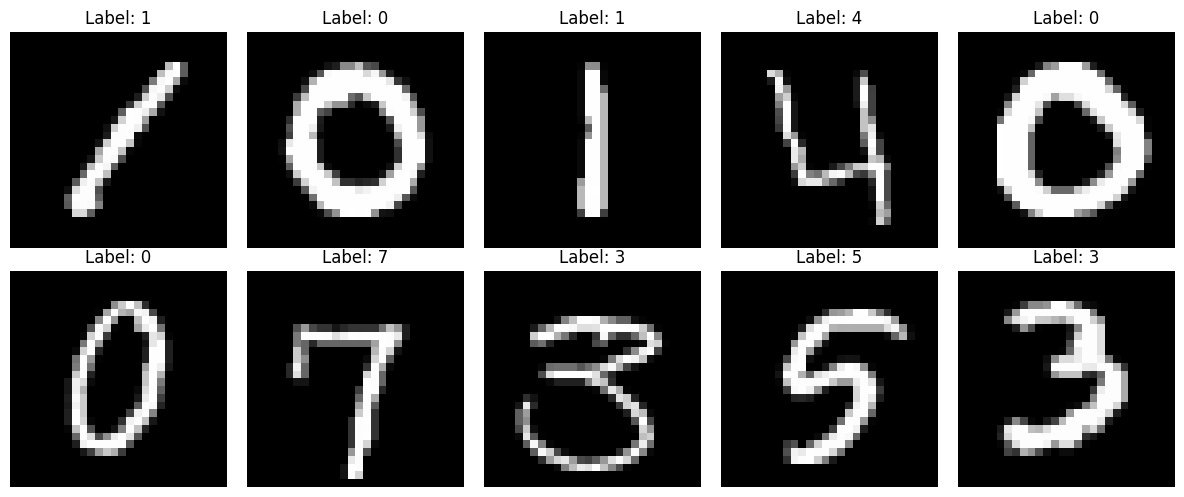

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

As expected: a variety of handwritten numbers. Now let's check the distribution of labels, just to make sure we don't have to weight the data

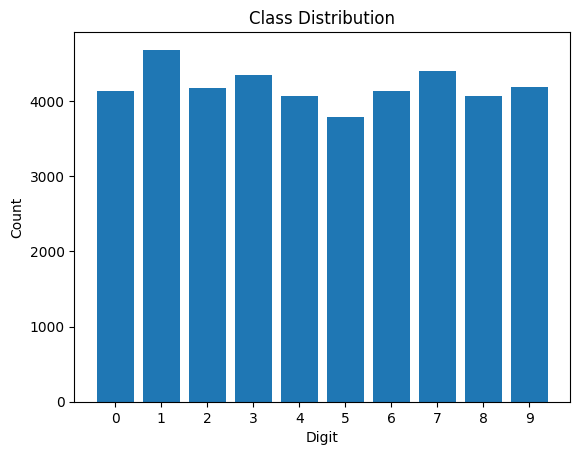

Counter({np.int64(1): 4684, np.int64(7): 4401, np.int64(3): 4351, np.int64(9): 4188, np.int64(2): 4177, np.int64(6): 4137, np.int64(0): 4132, np.int64(4): 4072, np.int64(8): 4063, np.int64(5): 3795})


In [5]:
import collections

counts = collections.Counter(y_train)
plt.bar(counts.keys(), counts.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(range(10))
plt.show()

print(counts)

For the most part, the labels are fairly distributed. Perhaps the difference between the frequency of '1' and '5' is cause for concern, but it's probably more trouble than it's worth. 

Now we add the channel dimension required by the CNN

In [6]:
# Add channel dimension for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"Training shape: {X_train.shape}")  # (42000, 28, 28, 1)

Training shape: (42000, 28, 28, 1)


Now we will want to preprocess the images a bit in order to solidify the robustness of the CNN. We will do vertical and horizontal shifts, zooming, and small rotations so as to not confuse '6' and '9' and also to keep the adjusted data reasonably recognizable as a number. 

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(X_train)

2026-06-03 19:29:51.606411: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780514991.898080      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780514991.981885      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780514992.697256      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780514992.697294      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780514992.697297      58 computation_placer.cc:177] computation placer alr

Now we will split the training data in to training and validation sets, with a 80/20 split. 

In [8]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


Finally, we construct the CNN. We have three layers of feature extraction which use a convolutional layer and a maxpooling layer. We use 'relu' as our activation function for the convolution and dense layers. We employ a dropout layer to reduce the chance of overfitting and finish with a dense softmax layer using softmax to get probabilities for each number. 

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-03 19:30:21.145680: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

Now it's time to train the CNN on the data. To compile, we will use ADAM as the optimizer and calculate loss using sparse_categorical_crossentropy. We also monitor performance using accuracy. We employ early stopping based on validation loss in order to save time and memory. 

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    datagen.flow(X_tr, y_tr, batch_size=64),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.8140 - loss: 0.5699 - val_accuracy: 0.9764 - val_loss: 0.0736
Epoch 2/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9420 - loss: 0.1946 - val_accuracy: 0.9852 - val_loss: 0.0485
Epoch 3/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.9590 - loss: 0.1369 - val_accuracy: 0.9885 - val_loss: 0.0369
Epoch 4/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9685 - loss: 0.1108 - val_accuracy: 0.9889 - val_loss: 0.0316
Epoch 5/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9712 - loss: 0.0986 - val_accuracy: 0.9845 - val_loss: 0.0485
Epoch 6/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9745 - loss: 0.0863 - val_accuracy: 0.9895 - val_loss: 0.0307
Epoch 7/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.9775 - loss: 0.0769 - val_accuracy: 0.9921 - val_loss: 0.0261
Epoch 8/50
525/525 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9798 - loss: 0.0707 - 

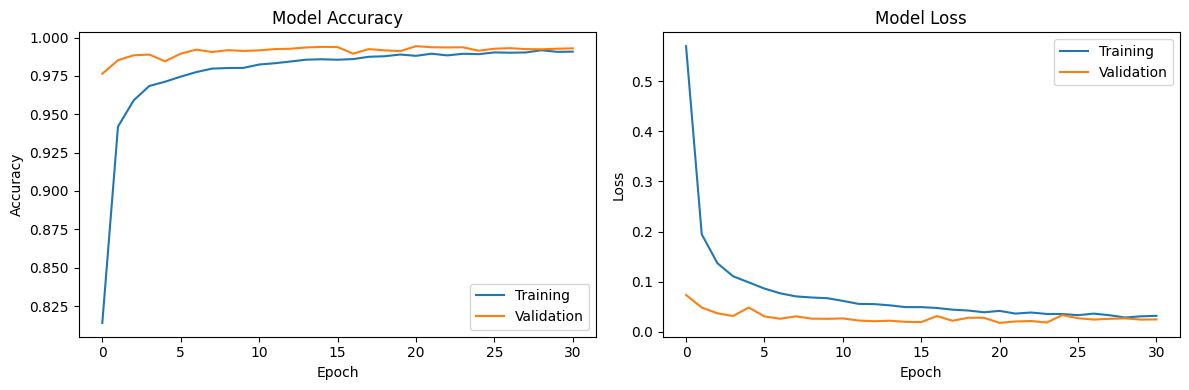

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Training')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

The model converges well before the 50 epoch limit, with both curves flattening around epoch 30. Both the training and validation curves flatten out quickly and there is no sign of over or under fitting. 

The validation accuracy being higher than the training is probably due to the data augmentation we performed. 

Now we make our predictions and submit our results to the competition. 

In [12]:
# Generate predictions
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)

# Create submission file
submission = pd.DataFrame({
    'ImageId': range(1, len(predictions) + 1),
    'Label': predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3


In this notebook, we trained a CNN on the MNIST handwritten numbers data set. By combing data augmentation and feature extraction layers, we were able to construct a CNN that very accureately recognizes handwritten numbers. This version scores a 0.99350 on Kaggle. 